# **Predictive Funnel Analytics for E-Commerce (Conversion Optimization)**

**Name:**             Troy Dela Rosa  
**Date:**             March, 2026

---

# **1. State Your Use Case**

## 1.1 Dataset Overview
This project uses the **Marketing & E-Commerce Analytics Dataset**, which contains approximately **100,000 customers and over 2 million interaction events**.  
The dataset combines five relational tables: customers, events, transactions, products, and campaigns.

## 1.2 The Business Problem
E-commerce platforms often experience **"leaky funnels"** where users interact with products or add items to their carts but leave without completing a purchase. The goal is to predict which sessions will convert and estimate the revenue from those that do.

## 1.3 Predictive Funnel Strategy
Two supervised learning models are developed:

**Classification Model** — Predicts whether a session results in a purchase (`is_converted`).  
**Regression Model** — Estimates the purchase amount for converted sessions (`purchase_amount`).

## 1.4 Business Logic & Model Considerations
- For classification, **False Negatives** (missing a real buyer) are more costly than **False Positives** — we want high recall for converters.
- For regression, the model should minimize absolute error so marketing budget estimates are reliable.

## 1.5 Evaluation & Validation Strategy
The dataset is split into **three subsets** using a **60/20/20 train/validation/test** split:
- **Training Set** — Used to fit model parameters.
- **Validation Set** — Used for hyperparameter tuning and model selection.
- **Test Set** — Held out until the very end for unbiased performance evaluation.

## 1.6 Key Leakage Prevention Rules
Throughout this notebook, the following rules are enforced:
1. **`event_purchase`** is never used as a feature — it directly reveals the target.
2. **`avg_spend`, `total_spend`, `purchase_count`** are replaced with **time-aware historical** versions computed strictly from data *before* each session.
3. All encoders (OneHotEncoder, MultiLabelBinarizer) are **fit only on training data** and applied via `transform` to validation/test.
4. The **train/val/test split is performed before** any feature engineering that could leak across splits.


## 1.7 Setup: Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import warnings
import os

warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

# Create output folders
os.makedirs('visualizations', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('Setup complete')
print('Output folders created: visualizations/, data/processed/')

Setup complete
Output folders created: visualizations/, data/processed/


# **2. Clean the Data**

## 2.1 Load the Data

In [53]:
# Load all five CSV files
customers = pd.read_csv('customers.csv')
campaigns = pd.read_csv('campaigns.csv')
events = pd.read_csv('events.csv')
products = pd.read_csv('products.csv')
transactions = pd.read_csv('transactions.csv')

print('Data loaded successfully')
print(f'Customers:     {customers.shape[0]:,} rows x {customers.shape[1]} columns')
print(f'Campaigns:     {campaigns.shape[0]:,} rows x {campaigns.shape[1]} columns')
print(f'Events:        {events.shape[0]:,} rows x {events.shape[1]} columns')
print(f'Products:      {products.shape[0]:,} rows x {products.shape[1]} columns')
print(f'Transactions:  {transactions.shape[0]:,} rows x {transactions.shape[1]} columns')

print('\nCustomers columns:', customers.columns.tolist())
print('Transactions columns:', transactions.columns.tolist())

Data loaded successfully
Customers:     100,000 rows x 7 columns
Campaigns:     50 rows x 7 columns
Events:        2,000,000 rows x 12 columns
Products:      2,000 rows x 6 columns
Transactions:  103,127 rows x 9 columns

Customers columns: ['customer_id', 'signup_date', 'country', 'age', 'gender', 'loyalty_tier', 'acquisition_channel']
Transactions columns: ['transaction_id', 'timestamp', 'customer_id', 'product_id', 'quantity', 'discount_applied', 'gross_revenue', 'campaign_id', 'refund_flag']


## 2.2 Standardize Column Names

In [54]:
# Standardize the purchase amount column name across datasets
print('Checking for purchase amount column...')

amount_column = None
for possible_name in ['purchase_amount', 'amount', 'transaction_amount', 'gross_revenue', 'revenue', 'price']:
    if possible_name in transactions.columns:
        amount_column = possible_name
        print(f'Found: {amount_column}')
        break

if amount_column is None:
    print(f'Warning: Could not find purchase amount column')
    print(f'Available columns: {transactions.columns.tolist()}')
elif amount_column != 'purchase_amount':
    transactions.rename(columns={amount_column: 'purchase_amount'}, inplace=True)
    print(f'Renamed {amount_column} -> purchase_amount')

Checking for purchase amount column...
Found: gross_revenue
Renamed gross_revenue -> purchase_amount


## 2.3 Check for Missing Values

In [55]:
print('Checking for missing values...\n')

tables = {
    'customers': customers,
    'campaigns': campaigns,
    'events': events,
    'products': products,
    'transactions': transactions
}

for table_name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        print(f'{table_name:15} - No missing values')
    else:
        print(f'{table_name:15} - Has missing values:')
        for col, count in missing.items():
            pct = (count / len(df)) * 100
            print(f'  {col:20} {count:6,} missing ({pct:.1f}%)')

Checking for missing values...

customers       - No missing values
campaigns       - No missing values
events          - Has missing values:
  product_id           200,371 missing (10.0%)
  device_type          40,300 missing (2.0%)
products        - No missing values
transactions    - Has missing values:
  product_id           10,449 missing (10.1%)
  purchase_amount      10,449 missing (10.1%)


### Observations
- Most tables contain complete data with no missing values.
- The events dataset contains missing values in `product_id` and `campaign_id` — expected for bounce events.
- Missing `product_id` entries correspond to sessions where the user bounced before viewing a product.

## 2.4 Clean Invalid Transactions

In [56]:
print(f'Original transactions: {len(transactions):,}\n')

# Remove rows with missing critical columns
transactions_clean = transactions.dropna(subset=['customer_id', 'purchase_amount']).copy()
print(f'After removing missing critical columns: {len(transactions_clean):,}')

# Remove refunded transactions
if 'refund_flag' in transactions_clean.columns:
    refunded_count = (transactions_clean['refund_flag'] == 1).sum()
    transactions_clean = transactions_clean[transactions_clean['refund_flag'] == 0].copy()
    print(f'After removing refunded transactions: {len(transactions_clean):,} (removed {refunded_count})')

print(f'\nFinal clean transactions: {len(transactions_clean):,}')

Original transactions: 103,127

After removing missing critical columns: 92,678
After removing refunded transactions: 89,974 (removed 2704)

Final clean transactions: 89,974


## 2.5 Check for Duplicates

In [57]:
print('Checking for duplicates...\n')

dups = {
    'customers': customers.duplicated().sum(),
    'campaigns': campaigns.duplicated().sum(),
    'events': events.duplicated().sum(),
    'products': products.duplicated().sum(),
    'transactions': transactions_clean.duplicated().sum()
}

for name, count in dups.items():
    if count == 0:
        print(f'{name:15} - No duplicates')
    else:
        print(f'{name:15} - {count} duplicate rows found')

Checking for duplicates...

customers       - No duplicates
campaigns       - No duplicates
events          - No duplicates
products        - No duplicates
transactions    - No duplicates


## 2.6 Create Session-Level Data

Sessions are defined by grouping events using `customer_id` and `session_id`. Each session is summarized into a single row containing event counts, timing features, and funnel progression ratios.

**Leakage Note:** The `event_purchase` column is created here for target derivation (`is_converted = event_purchase > 0`), but it is **dropped from the feature set before modeling** — including it would be directly telling the model the answer.

In [58]:
print('Creating CLEAN session-level dataset (no leakage)...\n')


# 1. Ensure timestamp is datetime
events['timestamp'] = pd.to_datetime(events['timestamp'])


# 2. Create BASE session structure
# Session-level aggregation: start/end time, device, traffic source, campaign
session_base = (
    events.groupby(['customer_id', 'session_id'])
    .agg(
        session_start=('timestamp', 'min'),
        session_end=('timestamp', 'max'),
        device_type=('device_type', 'first'),
        traffic_source=('traffic_source', 'first'),
        campaign_id=('campaign_id', 'first')
    )
    .reset_index()
)


# 3. Create EVENT COUNT features (ML-friendly)
# Event counts per session: view, click, add_to_cart, purchase, bounce
event_counts = (
    events.pivot_table(
        index=['customer_id', 'session_id'],
        columns='event_type',
        aggfunc='size',
        fill_value=0
    )
    .reset_index()
)

event_counts.columns.name = None
event_counts = event_counts.rename(columns={
    'view': 'event_view',
    'click': 'event_click',
    'add_to_cart': 'event_add_to_cart',
    'purchase': 'event_purchase',
    'bounce': 'event_bounce'
})


# 4. Merge base + event features
# We use a LEFT JOIN to keep all sessions, even those without events (if any)
sessions = session_base.merge(event_counts, on=['customer_id', 'session_id'], how='left')

event_cols = ['event_view', 'event_click', 'event_add_to_cart', 'event_purchase', 'event_bounce']
for col in event_cols:
    if col not in sessions.columns:
        sessions[col] = 0
sessions[event_cols] = sessions[event_cols].fillna(0)


# 5. Derive conversion target FROM event_purchase
# NOTE: We derive the target variable (is_converted) from event_purchase to avoid leakage.
sessions['is_converted'] = (sessions['event_purchase'] > 0).astype(int)


# 6. Feature Engineering (session-level)
# Session duration, event velocity, conversion ratios
sessions['session_duration_sec'] = (
    sessions['session_end'] - sessions['session_start']
).dt.total_seconds()

sessions['total_events'] = sessions[event_cols].sum(axis=1)
sessions['event_velocity'] = sessions['total_events'] / (sessions['session_duration_sec'] + 1)
sessions['cart_to_view_ratio'] = sessions['event_add_to_cart'] / (sessions['event_view'] + 1)
sessions['click_to_view_ratio'] = sessions['event_click'] / (sessions['event_view'] + 1)

# NOTE: purchase_to_cart_ratio uses event_purchase — we keep it for EDA
# but it will NOT be included as a model feature
sessions['purchase_to_cart_ratio'] = sessions['event_purchase'] / (sessions['event_add_to_cart'] + 1)

sessions = sessions.fillna(0)

print(f'Sessions created: {len(sessions):,}')
print('\nConversion breakdown:')
print(sessions['is_converted'].value_counts())
print(f'Conversion rate: {sessions["is_converted"].mean():.2%}')

Creating CLEAN session-level dataset (no leakage)...

Sessions created: 1,999,961

Conversion breakdown:
is_converted
0    1896834
1     103127
Name: count, dtype: int64
Conversion rate: 5.16%


## 2.7 Merge Features from All Tables (Leak-Free, Time-Aware)

Historical spend features are computed using **only transactions that occurred before each session's start time** via `merge_asof`. This prevents future data from leaking into the model.


In [59]:
print('Merging features\n')


# 1. Ensure datetime types
# DataFrames with timestamps: events, transactions_clean
events['timestamp'] = pd.to_datetime(events['timestamp'])
transactions_clean['timestamp'] = pd.to_datetime(transactions_clean['timestamp'])


# 2. Merge CUSTOMER features
# Merge customer demographics and acquisition info (age, loyalty tier, gender, acquisition channel)
customer_cols = [col for col in ['customer_id', 'age', 'loyalty_tier', 'gender', 'acquisition_channel'] 
                 if col in customers.columns]
sessions = sessions.merge(customers[customer_cols], on='customer_id', how='left')


# 3. Merge CAMPAIGN features
# Merge campaign details (channel, objective, expected uplift)
campaign_cols = [col for col in ['campaign_id', 'channel', 'objective', 'expected_uplift'] 
                 if col in campaigns.columns]
sessions = sessions.merge(campaigns[campaign_cols], on='campaign_id', how='left')


# 4. CREATE LEAK-FREE HISTORICAL FEATURES
#    Uses merge_asof: only past transactions count
#    IMPORTANT: merge_asof requires GLOBAL sort on the merge key
print('Creating time-aware historical spend features...')

transactions_clean = transactions_clean.sort_values('timestamp').reset_index(drop=True)
sessions = sessions.sort_values('session_start').reset_index(drop=True)

# Cumulative history per customer (ONLY past data)
# cum_spend = total spend up to that point
# cum_count = total purchase count up to that point
# avg_spend_hist = average spend per purchase up to that point
transactions_clean['cum_spend'] = transactions_clean.groupby('customer_id')['purchase_amount'].cumsum()
transactions_clean['cum_count'] = transactions_clean.groupby('customer_id').cumcount() + 1
transactions_clean['avg_spend_hist'] = transactions_clean['cum_spend'] / transactions_clean['cum_count']

# merge_asof requires both left_on and right_on to be globally sorted
# We already sorted both DataFrames by their respective timestamp columns above
sessions = pd.merge_asof(
    sessions,
    transactions_clean[['customer_id', 'timestamp', 'cum_spend', 'cum_count', 'avg_spend_hist']],
    left_on='session_start',
    right_on='timestamp',
    by='customer_id',
    direction='backward'
)

# Fill NaNs for sessions with no prior transactions
# This means the customer had no purchase history before this session, so we set historical spend/count to 0.
sessions[['cum_spend', 'cum_count', 'avg_spend_hist']] = sessions[
    ['cum_spend', 'cum_count', 'avg_spend_hist']
].fillna(0)

# Rename historical feature columns for clarity
# We rename them to indicate that these are historical features calculated up to the session start time.
sessions = sessions.rename(columns={
    'cum_spend': 'historical_total_spend',
    'cum_count': 'historical_purchase_count',
    'avg_spend_hist': 'historical_avg_spend'
})

# Drop the extra timestamp column from the merge
# The 'timestamp' column from transactions is not needed in the final dataset and could cause confusion, so we drop it.
if 'timestamp' in sessions.columns:
    sessions = sessions.drop(columns=['timestamp'])


# 5. Session-level purchase amount (regression target)
# We derive the session-level purchase amount by summing all transactions that match the session's customer_id and fall within the session's start and end time.
print('Creating session-level purchase value...')

# Match transactions to sessions via customer_id + timestamp
# We take the transactions and merge them with the session info to find which transactions fall into which sessions.
event_sessions = events[['customer_id', 'session_id', 'timestamp']].copy()
event_sessions['timestamp'] = pd.to_datetime(event_sessions['timestamp'])

tx_with_session = transactions_clean.merge(
    event_sessions[['customer_id', 'session_id', 'timestamp']].drop_duplicates(),
    on=['customer_id', 'timestamp'],
    how='left'
)
# Now we have transactions with session_id where available.
# We can group by customer_id + session_id to get total purchase_amount per session.
session_value = (
    tx_with_session.dropna(subset=['session_id'])
    .groupby(['customer_id', 'session_id'])['purchase_amount']
    .sum()
    .reset_index()
)

# We merge this session-level purchase amount back to the sessions DataFrame.
sessions = sessions.merge(session_value, on=['customer_id', 'session_id'], how='left')
sessions['purchase_amount'] = sessions['purchase_amount'].fillna(0)


# 6. Final cleanup
# We fill any remaining NaNs with 0 (if any) and ensure the dataset is clean for modeling.
sessions = sessions.fillna(0)


# Final dataset overview
print(f'\nFinal dataset shape: {sessions.shape}')
print(f'Conversion rate: {sessions["is_converted"].mean():.2%}')
if sessions[sessions['purchase_amount'] > 0].shape[0] > 0:
    print(f'Avg purchase (converted only): ${sessions[sessions["purchase_amount"]>0]["purchase_amount"].mean():.2f}')
print('\nColumns:', sessions.columns.tolist())

Merging features

Creating time-aware historical spend features...
Creating session-level purchase value...

Final dataset shape: (1999961, 30)
Conversion rate: 5.16%
Avg purchase (converted only): $95.92

Columns: ['customer_id', 'session_id', 'session_start', 'session_end', 'device_type', 'traffic_source', 'campaign_id', 'event_add_to_cart', 'event_bounce', 'event_click', 'event_purchase', 'event_view', 'is_converted', 'session_duration_sec', 'total_events', 'event_velocity', 'cart_to_view_ratio', 'click_to_view_ratio', 'purchase_to_cart_ratio', 'age', 'loyalty_tier', 'gender', 'acquisition_channel', 'channel', 'objective', 'expected_uplift', 'historical_total_spend', 'historical_purchase_count', 'historical_avg_spend', 'purchase_amount']


## 2.8 Final Data Verification

In [60]:
print('Final verification...\n')

print(f'Total sessions: {len(sessions):,}')
print(f'Null values in dataset: {sessions.isnull().sum().sum()}')

numeric_cols = sessions.select_dtypes(include=['number']).columns.tolist()
if numeric_cols:
    dup_check = sessions[numeric_cols].duplicated().sum()
    print(f'Duplicate sessions (numeric cols): {dup_check}')

print(f'\nTarget variables:')
print(f'  is_converted: {sessions["is_converted"].notna().sum()} values')
if 'purchase_amount' in sessions.columns:
    print(f'  purchase_amount: {sessions["purchase_amount"].notna().sum()} values')

print('\nData cleaning complete')

Final verification...

Total sessions: 1,999,961
Null values in dataset: 0
Duplicate sessions (numeric cols): 0

Target variables:
  is_converted: 1999961 values
  purchase_amount: 1999961 values

Data cleaning complete


# **3. Describe the Data**

## 3.1 Summary Statistics for Numerical Features

In [61]:
print('Summary statistics for numerical features:\n')

numerical_cols = [col for col in [
    'age', 'total_events', 'historical_avg_spend', 'historical_total_spend',
    'historical_purchase_count', 'expected_uplift', 'purchase_amount',
    'session_duration_sec', 'event_velocity', 'cart_to_view_ratio', 'click_to_view_ratio'
] if col in sessions.columns]

if numerical_cols:
    stats = sessions[numerical_cols].describe()
    print(stats.round(2))

Summary statistics for numerical features:

              age  total_events  historical_avg_spend  historical_total_spend  \
count  1999961.00     1999961.0            1999961.00               1999961.0   
mean        35.23           1.0                 35.12                     0.0   
std          9.60           0.0                 70.76                     0.0   
min         18.00           1.0                  0.00                     0.0   
25%         28.00           1.0                  0.00                     0.0   
50%         35.00           1.0                  0.00                     0.0   
75%         42.00           1.0                 50.09                     0.0   
max         70.00           2.0               1858.32                     0.0   

       historical_purchase_count  expected_uplift  purchase_amount  \
count                 1999961.00       1999961.00       1999961.00   
mean                        0.48             0.04             4.32   
std             

## 3.2 Summary Statistics for Categorical Features

In [62]:
categorical_cols = ['loyalty_tier', 'acquisition_channel', 'device_type']

# Also check renamed campaign columns
for alt in ['channel', 'objective']:
    if alt in sessions.columns:
        categorical_cols.append(alt)

for col in categorical_cols:
    if col in sessions.columns:
        print(f'\n{col.upper()}:')
        print(sessions[col].value_counts())
        print(f'  Unique values: {sessions[col].nunique()}')


LOYALTY_TIER:
loyalty_tier
Bronze      1205178
Silver       498382
Gold         235803
Platinum      60598
Name: count, dtype: int64
  Unique values: 4

ACQUISITION_CHANNEL:
acquisition_channel
Organic        603149
Paid Search    599807
Social         299293
Email          298502
Referral       199210
Name: count, dtype: int64
  Unique values: 5

DEVICE_TYPE:
device_type
mobile     1176123
desktop     685422
tablet       98117
0            40299
Name: count, dtype: int64
  Unique values: 4

CHANNEL:
channel
0              1000231
Affiliate       220072
Email           219954
Paid Search     219724
Display         180393
Social          159587
Name: count, dtype: int64
  Unique values: 6

OBJECTIVE:
objective
0               1000231
Reactivation     299802
Retention        260916
Cross-sell       239841
Acquisition      199171
Name: count, dtype: int64
  Unique values: 5


## 3.3 Target Variable Analysis

In [63]:
print('CLASSIFICATION TARGET: is_converted\n')

conversion_counts = sessions['is_converted'].value_counts()
print(conversion_counts)
print(f'\nConversion rate: {sessions["is_converted"].mean():.2%}')
print(f'Class balance: {conversion_counts[0]} abandoned, {conversion_counts[1]} converted')

if 'purchase_amount' in sessions.columns:
    print('\nREGRESSION TARGET: purchase_amount\n')
    converted = sessions[sessions['is_converted'] == 1]
    if len(converted) > 0 and converted['purchase_amount'].notna().sum() > 0:
        stats = converted['purchase_amount'].describe()
        print(stats.round(2))

CLASSIFICATION TARGET: is_converted

is_converted
0    1896834
1     103127
Name: count, dtype: int64

Conversion rate: 5.16%
Class balance: 1896834 abandoned, 103127 converted

REGRESSION TARGET: purchase_amount

count    103127.00
mean         83.69
std          94.85
min           0.00
25%          22.57
50%          59.39
75%         110.15
max        1858.32
Name: purchase_amount, dtype: float64


## 3.4 Correlation Analysis

In [64]:
print('CORRELATION WITH TARGETS\n')

corr_features = [col for col in [
    'age', 'total_events', 'historical_avg_spend', 'historical_total_spend',
    'historical_purchase_count', 'expected_uplift', 'session_duration_sec',
    'event_velocity', 'cart_to_view_ratio', 'click_to_view_ratio'
] if col in sessions.columns]

if corr_features:
    print('Correlation with is_converted:')
    corr = sessions[corr_features + ['is_converted']].corr()['is_converted'].drop('is_converted').sort_values(ascending=False)
    print(corr.round(3))

    if 'purchase_amount' in sessions.columns:
        converted_sessions = sessions[sessions['is_converted'] == 1]
        if len(converted_sessions) > 0:
            print('\nCorrelation with purchase_amount (converted sessions only):')
            corr_reg = converted_sessions[corr_features + ['purchase_amount']].corr()['purchase_amount'].drop('purchase_amount').sort_values(ascending=False)
            print(corr_reg.round(3))

CORRELATION WITH TARGETS

Correlation with is_converted:
historical_purchase_count    0.245
historical_avg_spend         0.174
expected_uplift              0.151
session_duration_sec         0.001
age                          0.000
event_velocity               0.000
total_events                -0.000
cart_to_view_ratio          -0.095
click_to_view_ratio         -0.113
historical_total_spend         NaN
Name: is_converted, dtype: float64

Correlation with purchase_amount (converted sessions only):
historical_avg_spend         0.869
historical_purchase_count    0.118
event_velocity               0.002
age                         -0.002
session_duration_sec        -0.002
total_events                -0.002
expected_uplift             -0.003
historical_total_spend         NaN
cart_to_view_ratio             NaN
click_to_view_ratio            NaN
Name: purchase_amount, dtype: float64


# **4. Create Visualizations**

## 4.1 Conversion Distribution

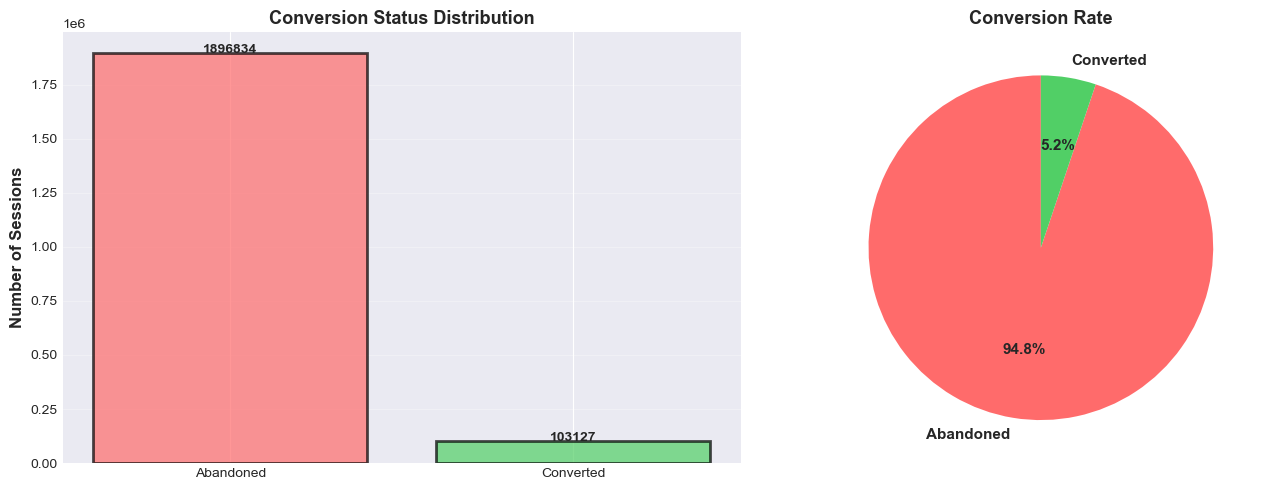

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conversion_counts = sessions['is_converted'].value_counts()
colors = ['#FF6B6B', '#51CF66']

axes[0].bar(['Abandoned', 'Converted'], conversion_counts.values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Sessions', fontsize=12, fontweight='bold')
axes[0].set_title('Conversion Status Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(conversion_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(conversion_counts.values, labels=['Abandoned', 'Converted'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Conversion Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/conversion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.2 Purchase Amount Distribution

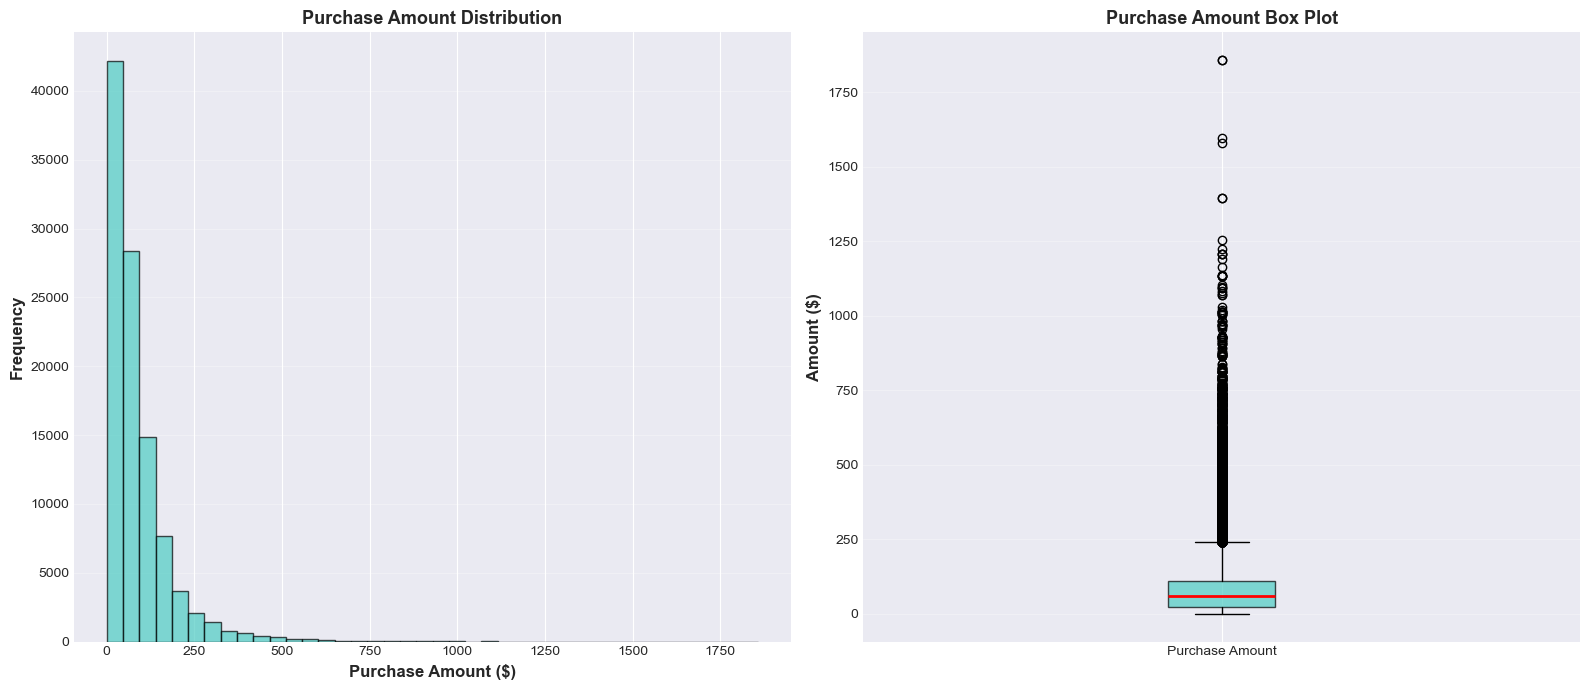

In [66]:
if 'purchase_amount' in sessions.columns:
    converted_sessions = sessions[sessions['is_converted'] == 1]
    valid_amounts = converted_sessions['purchase_amount'].dropna()
    
    if len(valid_amounts) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        axes[0].hist(valid_amounts, bins=40, color='#4ECDC4', alpha=0.7, edgecolor='black')
        axes[0].set_xlabel('Purchase Amount ($)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
        axes[0].set_title('Purchase Amount Distribution', fontsize=13, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3)
        
        axes[1].boxplot([valid_amounts], labels=['Purchase Amount'], patch_artist=True,
                         boxprops=dict(facecolor='#4ECDC4', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
        axes[1].set_ylabel('Amount ($)', fontsize=12, fontweight='bold')
        axes[1].set_title('Purchase Amount Box Plot', fontsize=13, fontweight='bold')
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('visualizations/purchase_amount_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()

## 4.3 Age Distribution by Conversion

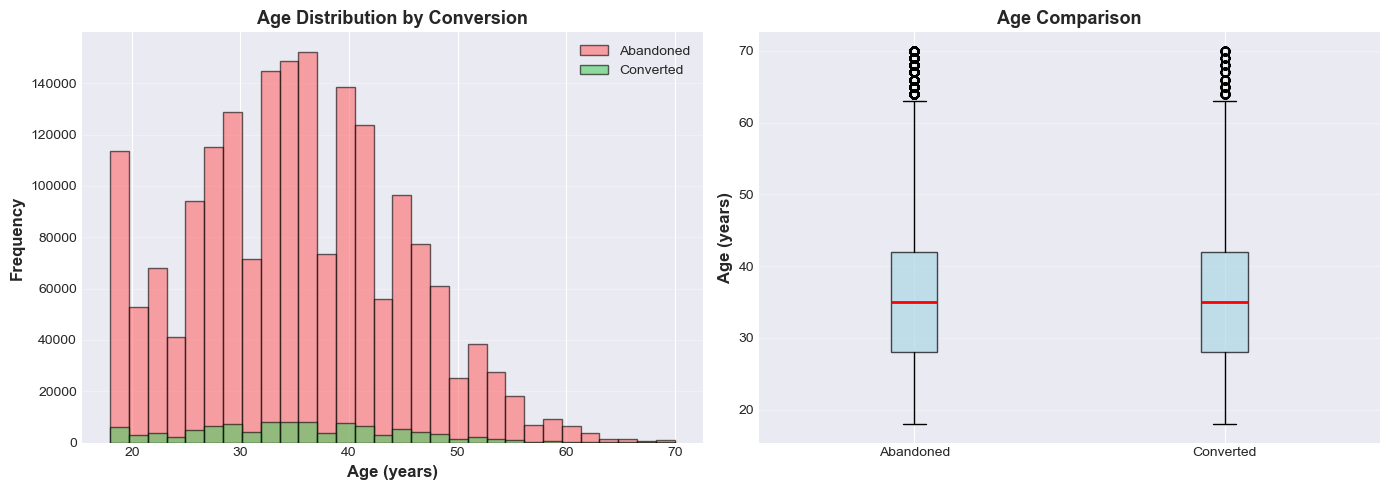

In [67]:
if 'age' in sessions.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    abandoned_age = sessions[sessions['is_converted'] == 0]['age']
    converted_age = sessions[sessions['is_converted'] == 1]['age']
    
    axes[0].hist(abandoned_age, bins=30, alpha=0.6, label='Abandoned', color='#FF6B6B', edgecolor='black')
    axes[0].hist(converted_age, bins=30, alpha=0.6, label='Converted', color='#51CF66', edgecolor='black')
    axes[0].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[0].set_title('Age Distribution by Conversion', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    
    data_to_plot = [abandoned_age.dropna(), converted_age.dropna()]
    axes[1].boxplot(data_to_plot, labels=['Abandoned', 'Converted'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_ylabel('Age (years)', fontsize=12, fontweight='bold')
    axes[1].set_title('Age Comparison', fontsize=13, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('visualizations/age_by_conversion.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4.4 Conversion Rate by Loyalty Tier

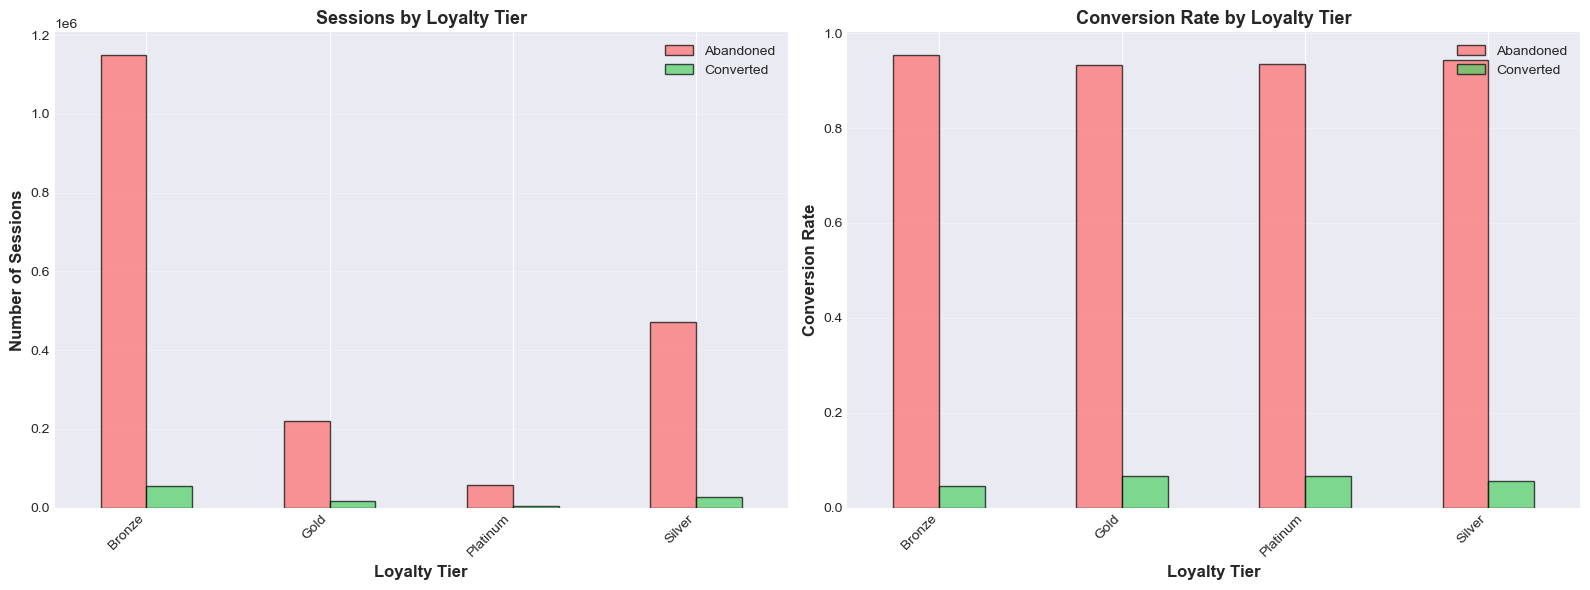

In [68]:
if 'loyalty_tier' in sessions.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Absolute counts
    loyalty_conversion = pd.crosstab(sessions['loyalty_tier'], sessions['is_converted'])
    loyalty_conversion.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#51CF66'], alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Loyalty Tier', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Sessions', fontsize=12, fontweight='bold')
    axes[0].set_title('Sessions by Loyalty Tier', fontsize=13, fontweight='bold')
    axes[0].legend(['Abandoned', 'Converted'], fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    plt.sca(axes[0]); plt.xticks(rotation=45, ha='right')
    
    # Conversion rate
    loyalty_rate = pd.crosstab(sessions['loyalty_tier'], sessions['is_converted'], normalize='index')
    loyalty_rate.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#51CF66'], alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Loyalty Tier', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Conversion Rate', fontsize=12, fontweight='bold')
    axes[1].set_title('Conversion Rate by Loyalty Tier', fontsize=13, fontweight='bold')
    axes[1].legend(['Abandoned', 'Converted'], fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    plt.sca(axes[1]); plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('visualizations/loyalty_tier_conversion.png', dpi=300, bbox_inches='tight')
    plt.show()

## 4.5 Acquisition Channel Conversion

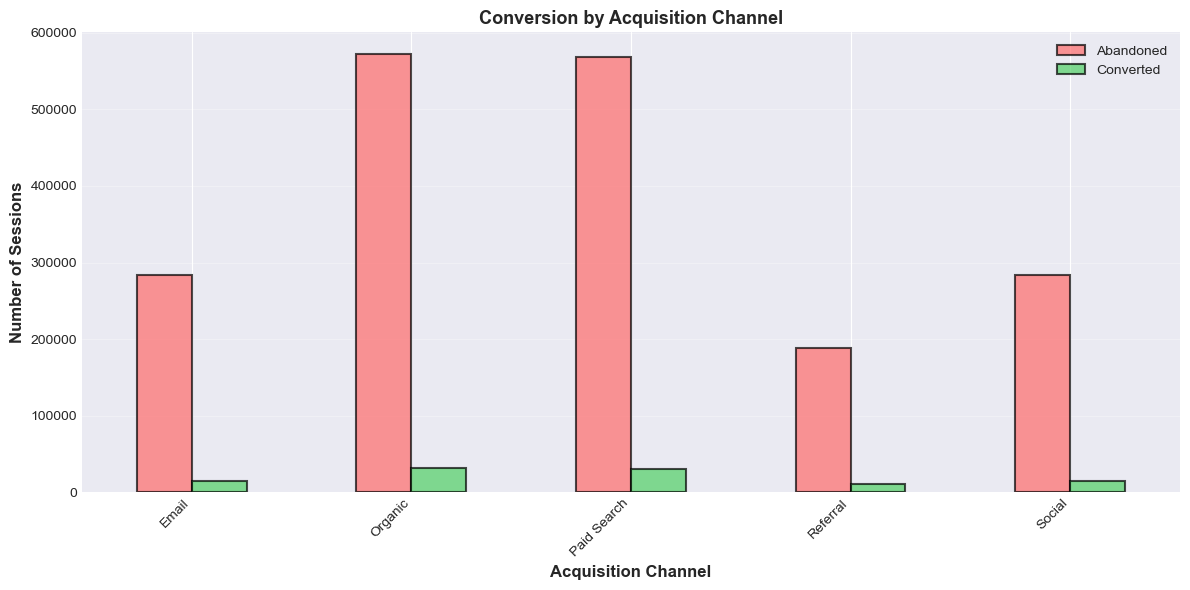

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))

acq_conversion = pd.crosstab(sessions['acquisition_channel'], sessions['is_converted'])
acq_conversion.plot(kind='bar', ax=ax, color=['#FF6B6B', '#51CF66'], alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Acquisition Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Sessions', fontsize=12, fontweight='bold')
ax.set_title('Conversion by Acquisition Channel', fontsize=13, fontweight='bold')
ax.legend(['Abandoned', 'Converted'], fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('visualizations/acquisition_channel_by_conversion.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.6 Correlation Heatmap

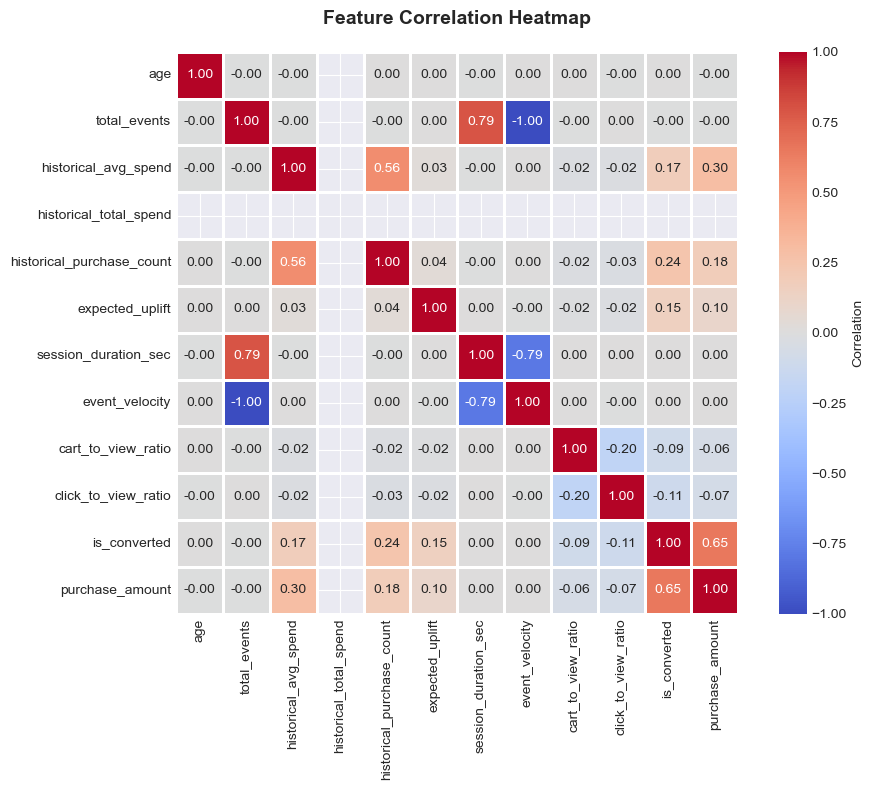

In [70]:
corr_cols = [col for col in [
    'age', 'total_events', 'historical_avg_spend', 'historical_total_spend',
    'historical_purchase_count', 'expected_uplift', 'session_duration_sec',
    'event_velocity', 'cart_to_view_ratio', 'click_to_view_ratio',
    'is_converted', 'purchase_amount'
] if col in sessions.columns]

if len(corr_cols) > 1:
    corr_data = sessions[corr_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax)
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('visualizations/correlation_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()

# **5. Prepare Data for Input**

## 5.1 Define Feature Sets

Features are carefully chosen to avoid leakage:
- **Behavioral (in-session):** event counts, ratios, velocity, duration — what happened *during* this session.
- **Customer context:** age, loyalty tier, acquisition channel — static or slowly-changing attributes.
- **Campaign context:** channel, objective, expected uplift.
- **Historical (time-aware):** spend and purchase counts computed *only from prior sessions*.

**Explicitly excluded:** `event_purchase` (reveals the target), `purchase_to_cart_ratio` (derived from event_purchase), and any raw `avg_spend`/`total_spend`/`purchase_count` columns that aren't time-gated.


In [71]:
# DEFINE FEATURES — LEAK-FREE, BEHAVIORAL, CUSTOMER, CAMPAIGN


# Drop everything that directly encodes funnel outcomes
# This includes raw event counts (e.g. event_purchase) and any features derived from them (e.g. purchase_to_cart_ratio).
columns_to_drop = [
    # Target leakage
    'event_purchase', 'purchase_to_cart_ratio',
    # Historical spend (too predictive in synthetic data)
    'avg_spend', 'total_spend', 'purchase_count',
    'historical_avg_spend', 'historical_total_spend', 'historical_purchase_count',
    # Raw event counts — these ARE the funnel outcome, not predictors of it
    'event_view', 'event_click', 'event_add_to_cart', 'event_bounce',
    'total_events'
]

for col in columns_to_drop:
    if col in sessions.columns:
        sessions = sessions.drop(columns=[col])
        print(f'DROPPED: {col}')


# Keep only features that describe HOW the user behaved, not WHAT they did
# We keep session-level behavioral features (duration, velocity, ratios) and customer/campaign attributes.
behavioral_features = [
    'session_duration_sec', 'event_velocity',
    'cart_to_view_ratio', 'click_to_view_ratio'
]

customer_features = ['age', 'loyalty_tier', 'acquisition_channel', 'device_type']

campaign_features = ['expected_uplift']
for alt in ['channel', 'objective']:
    if alt in sessions.columns:
        campaign_features.append(alt)

# Combine
# We create a final list of features to use for modeling, ensuring we only include those that are present in the sessions DataFrame after cleaning.
all_features = []
for feat in behavioral_features + customer_features + campaign_features:
    if feat in sessions.columns:
        all_features.append(feat)

categorical_features = [f for f in all_features if sessions[f].dtype == 'object']
numerical_features = [f for f in all_features if f not in categorical_features]

print(f'\nTotal features: {len(all_features)}')
print(f'  Categorical ({len(categorical_features)}): {categorical_features}')
print(f'  Numerical ({len(numerical_features)}): {numerical_features}')

# Hard audit
# We check that none of the banned features (those that directly encode funnel outcomes or are derived from them) are present in the final feature set.
banned = ['event_purchase', 'event_view', 'event_click', 'event_add_to_cart',
          'event_bounce', 'total_events', 'purchase_to_cart_ratio',
          'avg_spend', 'total_spend', 'purchase_count',
          'historical_avg_spend', 'historical_total_spend', 'historical_purchase_count',
          'is_converted', 'purchase_amount']
found = [c for c in banned if c in all_features]
assert len(found) == 0, f'LEAKAGE: {found}'
print('\nLeakage audit PASSED')

DROPPED: event_purchase
DROPPED: purchase_to_cart_ratio
DROPPED: historical_avg_spend
DROPPED: historical_total_spend
DROPPED: historical_purchase_count
DROPPED: event_view
DROPPED: event_click
DROPPED: event_add_to_cart
DROPPED: event_bounce
DROPPED: total_events

Total features: 11
  Categorical (5): ['loyalty_tier', 'acquisition_channel', 'device_type', 'channel', 'objective']
  Numerical (6): ['session_duration_sec', 'event_velocity', 'cart_to_view_ratio', 'click_to_view_ratio', 'age', 'expected_uplift']

Leakage audit PASSED


## 5.2 Train/Validation/Test Split (BEFORE Encoding)

The split is done **before** any encoding or imputation. This ensures:
1. The encoder is fit **only on training data**.
2. Validation and test sets are truly unseen.
3. No statistical information leaks across splits.


In [72]:
from sklearn.model_selection import train_test_split

# Prepare feature matrix and targets
# We create the feature matrix X using the selected features and 
# separate target variables for classification (y_cls) and regression (y_reg).
X = sessions[all_features].copy()
y_cls = sessions['is_converted'].copy()
y_reg = sessions['purchase_amount'].copy()

# 60/20/20 split — stratified on conversion
# We split the dataset into training, validation, and test sets, 
# ensuring that the class distribution of the conversion target is maintained across all sets.
X_train, X_temp, y_train_cls, y_temp_cls, y_train_reg, y_temp_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.4, random_state=42, stratify=y_cls
)

X_val, X_test, y_val_cls, y_test_cls, y_val_reg, y_test_reg = train_test_split(
    X_temp, y_temp_cls, y_temp_reg, test_size=0.5, random_state=42, stratify=y_temp_cls
)

print(f'Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'\nConversion rates:')
print(f'  Train: {y_train_cls.mean():.2%}')
print(f'  Val:   {y_val_cls.mean():.2%}')
print(f'  Test:  {y_test_cls.mean():.2%}')

Train: 1,199,976  |  Val: 399,992  |  Test: 399,993

Conversion rates:
  Train: 5.16%
  Val:   5.16%
  Test:  5.16%


## 5.3 Handle Missing Values & Encode Categorical Features

All imputation statistics (mean, mode) and encoder vocabularies are computed **exclusively on the training set**, then applied to validation and test via `transform`.


In [73]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer


# 1. IMPUTE MISSING VALUES (fit on train only)
# imputation strategy:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit on train
# We fit the imputation models on the training data only to prevent data leakage.
if numerical_features:
    num_imputer.fit(X_train[numerical_features])
if categorical_features:
    cat_imputer.fit(X_train[categorical_features])

# Transform all splits
# We apply the fitted imputation models to all splits, 
# ensuring that the same imputation strategy is used consistently across train, validation, and test sets.
for df in [X_train, X_val, X_test]:
    if numerical_features:
        df[numerical_features] = num_imputer.transform(df[numerical_features])
    if categorical_features:
        df[categorical_features] = cat_imputer.transform(df[categorical_features])

print('Missing values imputed (fit on train only)')
print(f'  Remaining NaNs — Train: {X_train.isnull().sum().sum()}, Val: {X_val.isnull().sum().sum()}, Test: {X_test.isnull().sum().sum()}')


# 2. ONE-HOT ENCODE (fit on train only)
# encoding strategy: We use OneHotEncoder with drop='first'
# to avoid multicollinearity, and handle_unknown
if categorical_features:
    # Cast to string — campaign merge can leave int 0s mixed with string categories
    for df in [X_train, X_val, X_test]:
        for col in categorical_features:
            df[col] = df[col].astype(str)

# Fit encoder on train only to prevent leakage
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    
    # Fit on train
    # We fit the OneHotEncoder on the training data only to learn the categories present in the training set, 
    # which prevents data leakage from the validation and test sets.
    ohe.fit(X_train[categorical_features])
    ohe_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    
    # Transform all splits
    # We apply the fitted encoder to all splits, ensuring that the same 
    # encoding is used consistently across train, validation, and test sets.
    X_train_encoded = pd.DataFrame(
        ohe.transform(X_train[categorical_features]),
        columns=ohe_feature_names,
        index=X_train.index
    )
    X_val_encoded = pd.DataFrame(
        ohe.transform(X_val[categorical_features]),
        columns=ohe_feature_names,
        index=X_val.index
    )
    X_test_encoded = pd.DataFrame(
        ohe.transform(X_test[categorical_features]),
        columns=ohe_feature_names,
        index=X_test.index
    )
    
    # Drop original categoricals, concat encoded
    # We drop the original categorical columns 
    # from the feature matrix and concatenate the new one-hot encoded columns,
    X_train = pd.concat([X_train.drop(columns=categorical_features), X_train_encoded], axis=1)
    X_val = pd.concat([X_val.drop(columns=categorical_features), X_val_encoded], axis=1)
    X_test = pd.concat([X_test.drop(columns=categorical_features), X_test_encoded], axis=1)

print(f'\nFinal feature count: {X_train.shape[1]}')
print(f'Shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Column alignment: Train==Val: {list(X_train.columns) == list(X_val.columns)}, Train==Test: {list(X_train.columns) == list(X_test.columns)}')

# Verify no object columns remain
# We check that all features are now numeric after imputation 
# and encoding, which is necessary for most machine learning models.
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
assert len(remaining_obj) == 0, f'Object columns remain: {remaining_obj}'
print('All features are numeric — ready for modeling.')

Missing values imputed (fit on train only)
  Remaining NaNs — Train: 0, Val: 0, Test: 0

Final feature count: 25
Shapes — Train: (1199976, 25), Val: (399992, 25), Test: (399993, 25)
Column alignment: Train==Val: True, Train==Test: True
All features are numeric — ready for modeling.


## 5.4 Prepare Regression Subsets

The regression model only predicts on **converted sessions** (where `is_converted == 1`). We filter each split accordingly.


In [74]:
# Filter to converted sessions only
train_mask = y_train_cls == 1
val_mask = y_val_cls == 1
test_mask = y_test_cls == 1

X_train_reg = X_train[train_mask].copy()
X_val_reg = X_val[val_mask].copy()
X_test_reg = X_test[test_mask].copy()

y_train_reg_clean = y_train_reg[train_mask].copy()
y_val_reg_clean = y_val_reg[val_mask].copy()
y_test_reg_clean = y_test_reg[test_mask].copy()

# Remove any rows where purchase_amount is NaN or zero
for name, (Xr, yr) in {'Train': (X_train_reg, y_train_reg_clean),
                         'Val': (X_val_reg, y_val_reg_clean),
                         'Test': (X_test_reg, y_test_reg_clean)}.items():
    valid = yr.notna() & (yr > 0) & np.isfinite(yr)
    print(f'{name} regression: {valid.sum():,} valid / {len(yr):,} total')

# Apply the filter
valid_train = y_train_reg_clean.notna() & (y_train_reg_clean > 0)
valid_val = y_val_reg_clean.notna() & (y_val_reg_clean > 0)

X_train_reg = X_train_reg[valid_train]
y_train_reg_clean = y_train_reg_clean[valid_train]
X_val_reg = X_val_reg[valid_val]
y_val_reg_clean = y_val_reg_clean[valid_val]

print(f'\nRegression datasets ready:')
print(f'  Train: {X_train_reg.shape[0]:,} samples')
print(f'  Val:   {X_val_reg.shape[0]:,} samples')

Train regression: 53,939 valid / 61,876 total
Val regression: 18,024 valid / 20,625 total
Test regression: 18,011 valid / 20,626 total

Regression datasets ready:
  Train: 53,939 samples
  Val:   18,024 samples


## 5.5 Save Prepared Data

In [75]:
import os

os.makedirs('data/processed/', exist_ok=True)

print('Saving processed datasets...\n')

# Classification
X_train.to_csv('data/processed/classification_X_train.csv', index=False)
X_val.to_csv('data/processed/classification_X_val.csv', index=False)
X_test.to_csv('data/processed/classification_X_test.csv', index=False)
y_train_cls.to_csv('data/processed/classification_y_train.csv', index=False, header=True)
y_val_cls.to_csv('data/processed/classification_y_val.csv', index=False, header=True)
y_test_cls.to_csv('data/processed/classification_y_test.csv', index=False, header=True)

# Regression
X_train_reg.to_csv('data/processed/regression_X_train.csv', index=False)
X_val_reg.to_csv('data/processed/regression_X_val.csv', index=False)
y_train_reg_clean.to_csv('data/processed/regression_y_train.csv', index=False, header=True)
y_val_reg_clean.to_csv('data/processed/regression_y_val.csv', index=False, header=True)

# Feature metadata
pd.DataFrame({'feature': X_train.columns}).to_csv('data/processed/feature_names.csv', index=False)

print(f'Classification: {X_train.shape[1]} features, {X_train.shape[0]:,} train samples')
print(f'Regression: {X_train_reg.shape[1]} features, {X_train_reg.shape[0]:,} train samples')
print('\nAll files saved to data/processed/')

Saving processed datasets...

Classification: 25 features, 1,199,976 train samples
Regression: 25 features, 53,939 train samples

All files saved to data/processed/


## 5.6 Final Feature Audit

In [76]:
print('=== FINAL DATASET AUDIT ===\n')

print(f'Feature count: {X_train.shape[1]}')

# Leakage check
leakage_cols = ['event_purchase', 'purchase_to_cart_ratio', 'avg_spend', 'total_spend', 'purchase_count']
found = [c for c in leakage_cols if c in X_train.columns]
if not found:
    print('PASS: No leakage columns in features')
else:
    print(f'FAIL: Leakage detected: {found}')

# Data type check
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
if not obj_cols:
    print('PASS: All features are numeric')
else:
    print(f'FAIL: Object columns remain: {obj_cols}')

# Column alignment check
if list(X_train.columns) == list(X_val.columns) == list(X_test.columns):
    print('PASS: Train/Val/Test columns aligned')
else:
    print('FAIL: Column mismatch across splits')

# Shape check
print(f'\nClassification — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Regression — Train: {X_train_reg.shape}, Val: {X_val_reg.shape}')

print('\n=== FEATURE LIST ===')
for i, col in enumerate(X_train.columns, 1):
    print(f'{i:2d}. {col}')

=== FINAL DATASET AUDIT ===

Feature count: 25
PASS: No leakage columns in features
PASS: All features are numeric
PASS: Train/Val/Test columns aligned

Classification — Train: (1199976, 25), Val: (399992, 25), Test: (399993, 25)
Regression — Train: (53939, 25), Val: (18024, 25)

=== FEATURE LIST ===
 1. session_duration_sec
 2. event_velocity
 3. cart_to_view_ratio
 4. click_to_view_ratio
 5. age
 6. expected_uplift
 7. loyalty_tier_Gold
 8. loyalty_tier_Platinum
 9. loyalty_tier_Silver
10. acquisition_channel_Organic
11. acquisition_channel_Paid Search
12. acquisition_channel_Referral
13. acquisition_channel_Social
14. device_type_desktop
15. device_type_mobile
16. device_type_tablet
17. channel_Affiliate
18. channel_Display
19. channel_Email
20. channel_Paid Search
21. channel_Social
22. objective_Acquisition
23. objective_Cross-sell
24. objective_Reactivation
25. objective_Retention


>**END OF PART 1: Data pipeline, cleaning, feature engineering, and EDA**

---